<a href="https://colab.research.google.com/github/yhkovska/Ecommerce-Analytics-Python/blob/main/Furniture_E_Commerce_Performance_Analytic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data overview**

**Dataset structure**

Total number of columns: **18**

Total number of unique sessions: **33 538**

Analyzed time range: **2020-11-01 - 2021-01-27**

**Data types**

Number of numeric columns: **5**

Number of categorical columns: **12**

Number of datetime columns: **1**

**Missing values**

Missing values:

| column             | Missing count       | Percent          (%) |
|--------------------|---------------------|----------------------|
| is_unsubscribed    | 30 757              | 91.71                |
| is_email_verified  | 30 757              | 91.71                |
| account_id         | 30 757              | 91.71                |
| browser_language   | 11 007              | 32.82                |

The highest share of missing values: 91.71% (30 757)

Reason: Most missing values are driven by unauthenticated users and data collection limitations.
These gaps are non-critical and do not impact core business metrics.

###**Exploratory Data Analysis**

In [ ]:
# importing libraries
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib import colormaps
from pandas.api.types import (
    is_numeric_dtype,
    is_datetime64_any_dtype,
    is_bool_dtype)
from scipy.stats import kruskal
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from itertools import combinations
from IPython.display import display, Markdown

In [ ]:
# connecting to the database
!pip install --upgrade google-cloud-bigquery
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
# SQL request
query = """
SELECT
  s.date AS order_date,
  o.ga_session_id AS session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language AS browser_language,
  sp.medium AS traffic_source_info,
  sp.channel AS traffic_channel,
  a.id AS account_id,
  a.is_verified AS is_email_verified,
  a.is_unsubscribed,
  p.category AS product_category,
  p.name AS product_name,
  p.price,
  p.short_description
FROM `DA.order` o
JOIN `DA.session` s
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `DA.session_params` sp
  ON sp.ga_session_id = s.ga_session_id
JOIN `DA.product` p
  ON p.item_id = o.item_id
LEFT JOIN `DA.account_session` acs
  ON acs.ga_session_id = s.ga_session_id
LEFT JOIN `DA.account` a
  ON a.id = acs.account_id;"""
query_job = client.query(query)
results = query_job.result()
df = results.to_dataframe()
df.to_csv('data_fr.csv', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_date           33538 non-null  dbdate 
 1   session_id           33538 non-null  Int64  
 2   continent            33538 non-null  object 
 3   country              33538 non-null  object 
 4   device               33538 non-null  object 
 5   browser              33538 non-null  object 
 6   mobile_model_name    33538 non-null  object 
 7   operating_system     33538 non-null  object 
 8   browser_language     22531 non-null  object 
 9   traffic_source_info  33538 non-null  object 
 10  traffic_channel      33538 non-null  object 
 11  account_id           2781 non-null   Int64  
 12  is_email_verified    2781 non-null   Int64  
 13  is_unsubscribed      2781 non-null   Int64  
 14  product_category     33538 non-null  object 
 15  product_name         33538 non-null 

In [ ]:
# exploring data types
df.dtypes

,0
order_date,dbdate
session_id,Int64
continent,object
country,object
device,object
browser,object
mobile_model_name,object
operating_system,object
browser_language,object
traffic_source_info,object


In [ ]:
df.head()

,order_date,session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source_info,traffic_channel,account_id,is_email_verified,is_unsubscribed,product_category,product_name,price,short_description
0,2020-11-06,7799937037,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,2020-11-10,4020421879,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(none),Direct,653378,1,0,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,2020-11-24,6717382496,Americas,United States,desktop,Chrome,Chrome,Web,en-us,referral,Social Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2020-11-26,2093497337,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(none),Direct,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,2020-12-03,9506718330,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"


In [ ]:
# exploring data
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

total_cols = df.shape[1]

numeric_cols = [
    i for i in df.columns
    if is_numeric_dtype(df[i])]

categorical_cols = [
    i for i in df.columns
    if (df[i].dtype == "object"
        or str(df[i].dtype) in ("string", "category"))
    and not is_datetime64_any_dtype(df[i])]

datetime_cols = [
    i for i in df.columns
    if is_datetime64_any_dtype(df[i])]

unique_sessions = df["session_id"].nunique()

start_date = df["order_date"].min()
end_date = df["order_date"].max()

missing_summary = (df.isna().sum().to_frame(name="missing_count").assign(
    missing_percent=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_count", ascending=False))


print(f"Total number of columns: {total_cols}")
print(f"Number of numeric columns: {len(numeric_cols)}, {numeric_cols}")
print(f"Number of categorical columns: {len(categorical_cols)}, {categorical_cols}")
print(f"Number of datetime columns: {len(datetime_cols)}, {datetime_cols}")
print(f"Number of unique sessions: {unique_sessions}")
print(f"Analyzed time range: from {start_date} to {end_date}")

Total number of columns: 18
Number of numeric columns: 5, ['session_id', 'account_id', 'is_email_verified', 'is_unsubscribed', 'price']
Number of categorical columns: 12, ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'browser_language', 'traffic_source_info', 'traffic_channel', 'product_category', 'product_name', 'short_description']
Number of datetime columns: 1, ['order_date']
Number of unique sessions: 33538
Analyzed time range: from 2020-11-01 00:00:00 to 2021-01-27 00:00:00


# **Sales and User Behavior analysis**

In [ ]:
# top3 continents by sales and orders visualization
continents_sales = (df.dropna(subset=['continent', 'price']).groupby('continent')['price'].sum().nlargest(3))
continents_orders = (df.dropna(subset=['continent', 'order_date']).groupby('continent')['order_date'].count().nlargest(3))

result = pd.concat([continents_sales, continents_orders], axis=1, keys=['total_sales', 'order_count'])
display(Markdown("**Top-3 continents by Sales and Orders Count**"))
result

**Top-3 continents by Sales and Orders Count**

,total_sales,order_count
continent,,
Americas,17665280.0,18553
Asia,7601298.3,7950
Europe,5934624.2,6261


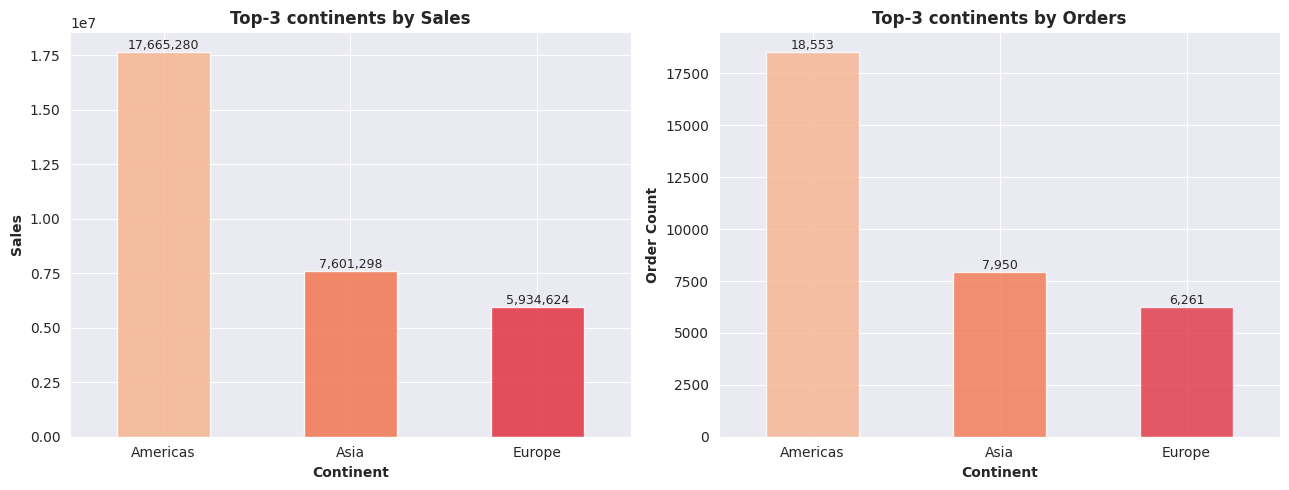

**Americas generates the highest revenue and has the largest number of orders**, making it the company’s key market at the moment.
Asia and Europe lag behind in comparison.

The company should either focus on attracting more customers in these regions or work on increasing the average order value.

In [ ]:
sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette("rocket_r")

# First subplot - Top-3 continents by Sales
continents_sales.plot(kind='bar',ax=axes[0], color=colors, alpha=0.85)
axes[0].set_title("Top-3 continents by Sales", fontweight='bold')
axes[0].set_xlabel("Continent", fontweight='semibold')
axes[0].set_ylabel("Sales", fontweight='semibold')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(continents_sales.values):
  axes[0].text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)

# Second subplot - Top-3 continents by Orders
continents_orders.plot(kind='bar',ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title("Top-3 continents by Orders", fontweight='bold')
axes[1].set_xlabel("Continent", fontweight='semibold')
axes[1].set_ylabel("Order Count", fontweight='semibold')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(continents_orders.values):
  axes[1].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


display(Markdown("""**Americas generates the highest revenue and has the largest number of orders**, making it the company’s key market at the moment.
Asia and Europe lag behind in comparison.

The company should either focus on attracting more customers in these regions or work on increasing the average order value."""))

In [ ]:
# top5 countries by sales and orders visualization
countries_sales = (df.dropna(subset=['country', 'price']).groupby('country')['price'].sum().nlargest(5))
countries_orders = (df.dropna(subset=['country', 'order_date']).groupby('country')['order_date'].count().nlargest(5))

result = pd.concat([countries_sales, countries_orders], axis=1, keys=['total_sales', 'order_count'])
display(Markdown("**Top-5 countries by Sales and Orders Count**"))
result

**Top-5 countries by Sales and Orders Count**

,total_sales,order_count
country,,
United States,13943553.9,14673
India,2809762.0,3029
Canada,2437921.0,2560
United Kingdom,938317.9,1029
France,710692.8,678


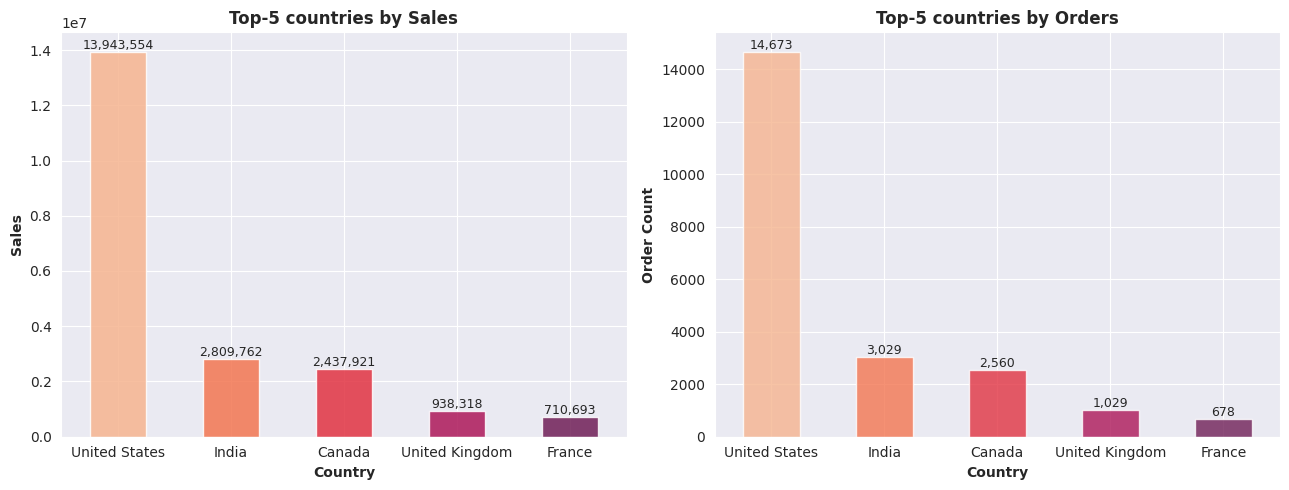

**The United States significantly outperforms all other countries in both revenue and order volume, indicating a dominant market position.**

**The United Kingdom and France** generate noticeably fewer orders and revenue compared to the leading markets.

Revenue distribution closely mirrors order distribution across countries, suggesting a strong correlation between order volume and total sales.

There is a sharp decline after the top three markets, with the **United Kingdom and France** contributing significantly lower sales and order volumes.

Markets outside the United States appear underpenetrated, which may indicate growth opportunities through targeted expansion strategies.

The distribution suggests that **revenue is primarily driven by a small number of key markets**, highlighting potential geographic concentration risk.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette("rocket_r")

# first subplot - Top-5 countries by Sales
countries_sales.plot(kind='bar',ax=axes[0], color=colors, alpha=0.85)
axes[0].set_title("Top-5 countries by Sales", fontweight='bold')
axes[0].set_xlabel("Country", fontweight='semibold')
axes[0].set_ylabel("Sales", fontweight='semibold')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(countries_sales.values):
  axes[0].text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)

# second subplot - Top-5 countries by Orders
countries_orders.plot(kind='bar',ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title("Top-5 countries by Orders", fontweight='bold')
axes[1].set_xlabel("Country", fontweight='semibold')
axes[1].set_ylabel("Order Count", fontweight='semibold')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(countries_orders.values):
  axes[1].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


display(Markdown("""**The United States significantly outperforms all other countries in both revenue and order volume, indicating a dominant market position.**

**The United Kingdom and France** generate noticeably fewer orders and revenue compared to the leading markets.

Revenue distribution closely mirrors order distribution across countries, suggesting a strong correlation between order volume and total sales.

There is a sharp decline after the top three markets, with the **United Kingdom and France** contributing significantly lower sales and order volumes.

Markets outside the United States appear underpenetrated, which may indicate growth opportunities through targeted expansion strategies.

The distribution suggests that **revenue is primarily driven by a small number of key markets**, highlighting potential geographic concentration risk."""))

In [ ]:
# top10 categories by total sales
categories_sales = (df.dropna(subset=['product_category', 'price']).groupby('product_category')['price'].sum().nlargest(10))

display(Markdown("**Top-10 categories by Total Sales**"))
categories_sales

**Top-10 categories by Total Sales**

,price
product_category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5
Outdoor furniture,2142222.2
Tables & desks,1790307.5
Chests of drawers & drawer units,906562.5
Bar furniture,735503.0


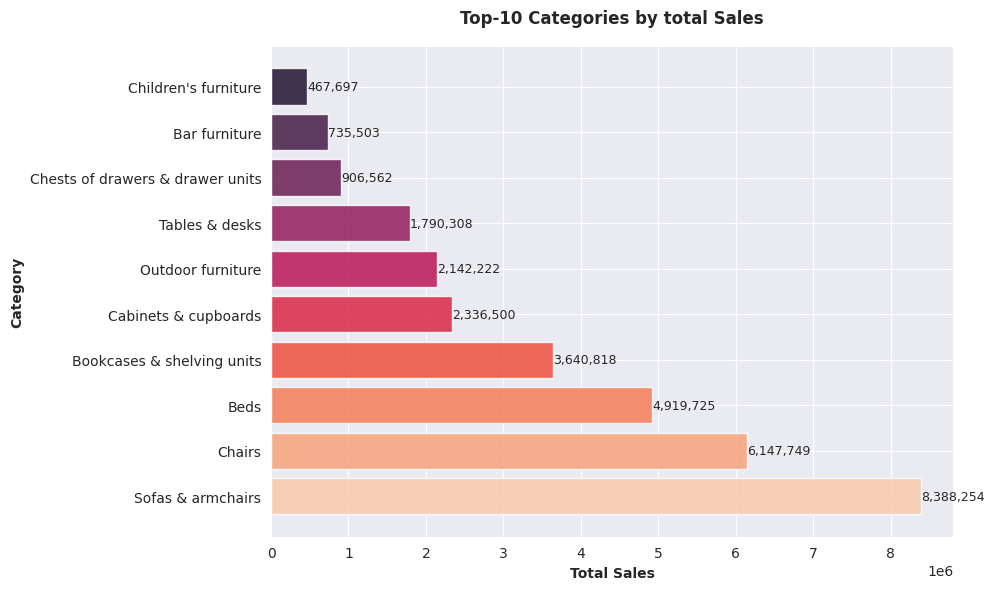

In [ ]:
plt.figure(figsize=(10,6))
colors = sns.color_palette("rocket_r", len(categories_sales))

ax = plt.barh(categories_sales.index, categories_sales.values, color=colors, alpha=0.85)

plt.title("Top-10 Categories by total Sales", fontweight='bold', y=1.03)
plt.xlabel("Total Sales", fontweight='semibold')
plt.ylabel("Category", fontweight='semibold')

for i, v in enumerate(categories_sales.values):
    plt.text(v, i, f"{v:,.0f}", va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# top10 categories in the highest-preforming country be sales
top_country = (df.dropna(subset=['country', 'price']).groupby('country')['price'].sum().idxmax())
categ_topcountry = (df[df['country'] == top_country].dropna(subset=['product_category', 'price']).groupby('product_category')['price'].sum().nlargest(10))

display(Markdown("**Top 10 product categories in the highest-performing country by sales**"))
print(top_country)
categ_topcountry


**Top 10 product categories in the highest-performing country by sales**

United States


,price
product_category,
Sofas & armchairs,3707144.5
Chairs,2619773.8
Beds,2213058.0
Bookcases & shelving units,1567606.9
Cabinets & cupboards,994545.5
Outdoor furniture,929245.2
Tables & desks,777865.0
Chests of drawers & drawer units,382388.0
Bar furniture,330805.0


In [ ]:
# comparison between top10 categories in global and country sales
display(Markdown("**Comparison**"))
comparison = (pd.concat([categories_sales, categ_topcountry], axis=1, keys=['global_sales', f'{top_country}_sales']).fillna(0))
comparison

**Comparison**

,global_sales,United States_sales
product_category,,
Sofas & armchairs,8388254.5,3707144.5
Chairs,6147748.8,2619773.8
Beds,4919725.0,2213058.0
Bookcases & shelving units,3640818.1,1567606.9
Cabinets & cupboards,2336499.5,994545.5
Outdoor furniture,2142222.2,929245.2
Tables & desks,1790307.5,777865.0
Chests of drawers & drawer units,906562.5,382388.0
Bar furniture,735503.0,330805.0


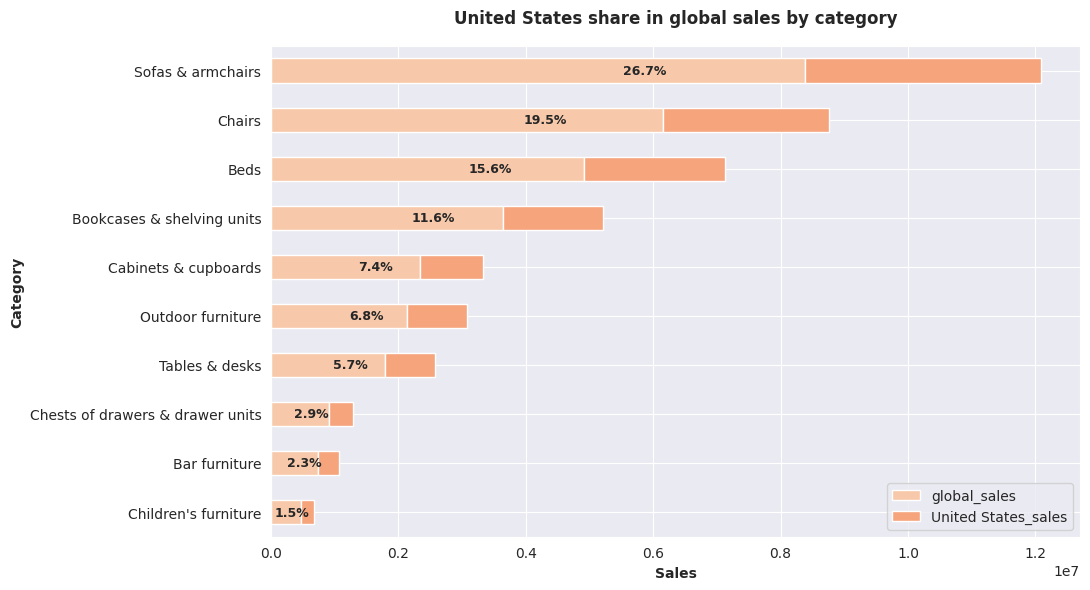

**United States** is the country with the highest sales.

The top product categories in the USA largely mirror the global trends, with **Sofas & Armchairs**, **Chairs**, and **Beds** leading.

There are no significant differences from the overall pattern - **the demand structure is consistent with the global distribution**.

In [ ]:
colors = sns.color_palette("rocket_r", len(comparison))

comparison_plot = comparison.sort_values('global_sales', ascending=True)

ax = comparison_plot.plot(kind='barh', stacked=True, figsize=(11,6), color=colors)

plt.title(f"{top_country} share in global sales by category", fontweight='bold', y=1.03)
plt.xlabel("Sales", fontweight='semibold')
plt.ylabel("Category", fontweight='semibold')

total_sales = comparison_plot['global_sales'].sum()
for i, (val, cat) in enumerate(zip(comparison_plot['global_sales'], comparison_plot.index)):
  percent = val / total_sales * 100
  ax.text(val * 0.7, i, f"{percent:.1f}%", va="center", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

display(Markdown("""**United States** is the country with the highest sales.

The top product categories in the USA largely mirror the global trends, with **Sofas & Armchairs**, **Chairs**, and **Beds** leading.

There are no significant differences from the overall pattern - **the demand structure is consistent with the global distribution**."""))

In [ ]:
# sales percentage by devices
device_sales_pctg = (df.dropna(subset=['device', 'price']).groupby('device')['price'].sum())
device_sales_pctg = (device_sales_pctg / device_sales_pctg.sum() * 100).round(2)

display(Markdown("**Sales by the Device type, %**"))
device_sales_pctg

**Sales by the Device type, %**

,price
device,
desktop,59.00
mobile,38.73
tablet,2.26


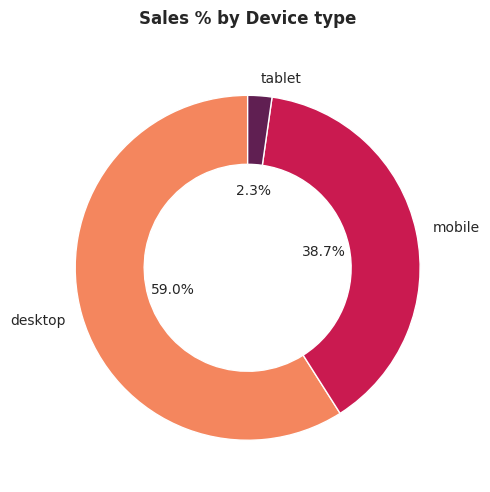

Sales are **heavily skewed** toward **desktop (~60%)**, whereas **tablets represent a minimal share (~2.3%)**, indicating limited contribution from mobile tablet devices.

In [ ]:
colors = sns.color_palette("rocket_r", len(device_sales_pctg))

plt.figure(figsize=(5,5))
plt.pie(device_sales_pctg,
        labels=device_sales_pctg.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.4),
        colors=colors,
        pctdistance=0.45,
        labeldistance=1.1
        )

plt.title('Sales % by Device type', fontweight='semibold', y=1.05)
plt.axis('equal')
plt.tight_layout()
plt.show()

display(Markdown("""Sales are **heavily skewed** toward **desktop (~60%)**, whereas **tablets represent a minimal share (~2.3%)**, indicating limited contribution from mobile tablet devices."""))

In [ ]:
# sales % by traffic channel
traffic_sales_pct = (df.dropna(subset=['traffic_channel', 'price']).groupby('traffic_channel')['price'].sum())
traffic_sales_pct = (traffic_sales_pct / traffic_sales_pct.sum() * 100).round(2)

display(Markdown('**Sales % by the Traffic Channel**'))
traffic_sales_pct

**Sales % by the Traffic Channel**

,price
traffic_channel,
Direct,23.44
Organic Search,35.76
Paid Search,26.62
Social Search,7.92
Undefined,6.26


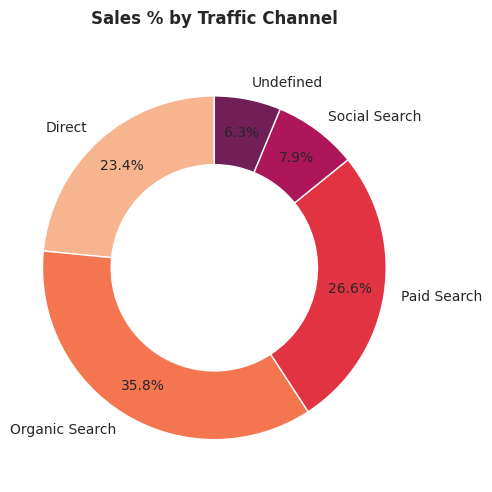

**Organic Search is the leading traffic source**, contributing 36% of total sales, followed by Paid Search (~27%) and Direct (23%).

Social Search (~8%) and Undefined (6%) channels have a relatively minor impact on overall revenue.

In [ ]:
colors = sns.color_palette("rocket_r")

plt.figure(figsize=(5,5))
plt.pie(traffic_sales_pct,
        labels=traffic_sales_pct.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.4),
        colors=colors,
        pctdistance=0.80,
        labeldistance=1.1
        )

plt.title('Sales % by Traffic Channel', fontweight='semibold', y=1.05)
plt.axis('equal')
plt.tight_layout()
plt.show()

display(Markdown("""**Organic Search is the leading traffic source**, contributing 36% of total sales, followed by Paid Search (~27%) and Direct (23%).

Social Search (~8%) and Undefined (6%) channels have a relatively minor impact on overall revenue."""))

In [ ]:
# percentage of verified users
registered_users = df.dropna(subset=['account_id'])

verified_acc = ((registered_users['is_email_verified'] == True).sum() / len(registered_users) * 100)
verified_acc = round(verified_acc, 2)

print(f'{verified_acc}% of registered users verified their email address.')

71.52% of registered users verified their email address.


In [ ]:
# percentage of unsubscribed users
unsubscribed_acc = ((registered_users['is_unsubscribed'] == True).sum() / len(registered_users) * 100)
unsubscribed_acc = round(unsubscribed_acc, 2)

print(f'{unsubscribed_acc}% of verified users unsubscribed from emails.')

16.07% of verified users unsubscribed from emails.


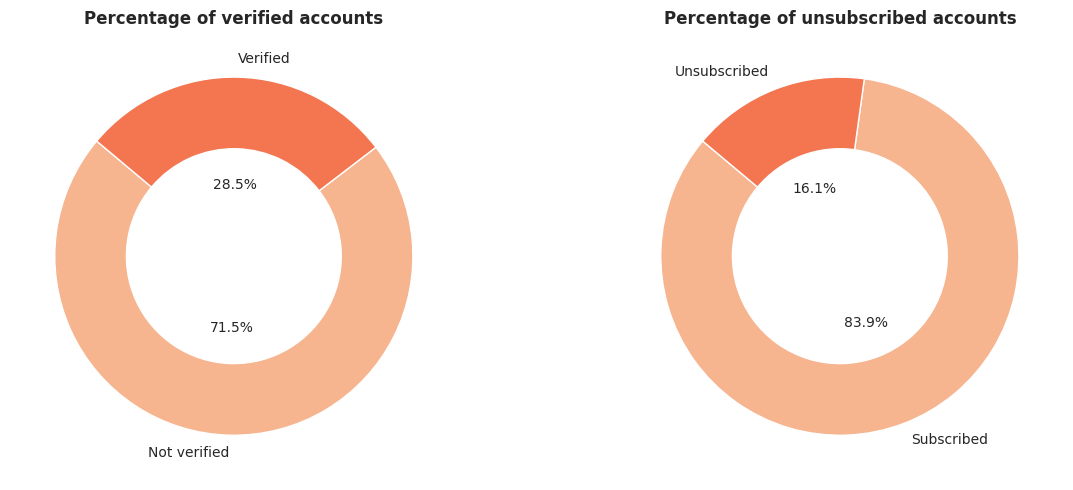

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette("rocket_r")

# verified
verified_counts = registered_users['is_email_verified'].value_counts()

axes[0].pie(
    verified_counts,
    labels=['Not verified', 'Verified'],
    autopct='%.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4),
    colors=colors,
    pctdistance=0.40,
    labeldistance=1.1
)
axes[0].set_title('Percentage of verified accounts', fontweight='semibold')


# unsubscribed
unsubscribed_counts = registered_users['is_unsubscribed'].value_counts()

axes[1].pie(
    unsubscribed_counts,
    labels=['Subscribed', 'Unsubscribed'],
    autopct='%.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4),
    colors=colors,
    pctdistance=0.40,
    labeldistance=1.1
)
axes[1].set_title('Percentage of unsubscribed accounts', fontweight='semibold')

plt.tight_layout()
plt.show()

In [ ]:
# user behaviour
unsubscribed_sales = (df.dropna(subset=['is_unsubscribed', 'price']).groupby('is_unsubscribed')['price']
                      .agg(['count', 'sum', 'mean'])
                      .rename(columns={'count': 'orders', 'sum': 'total_sales', 'mean': 'avg_order_value'}))

unsubscribed_sales.index = unsubscribed_sales.index.map({0: 'subscribed', 1: 'unsubscribed'})

unsubscribed_sales['total_sales'] = unsubscribed_sales['total_sales'].round(2)
unsubscribed_sales['avg_order_value'] = unsubscribed_sales['avg_order_value'].round(2)

display(Markdown("**Subscribed / Unsubscribed Users` behaviour**"))
unsubscribed_sales

**Subscribed / Unsubscribed Users` behaviour**

,orders,total_sales,avg_order_value
is_unsubscribed,,,
subscribed,2334,2150796.9,921.51
unsubscribed,447,431721.6,965.82


In [ ]:
top_countries_registered = (df.dropna(subset=['account_id', 'country']).groupby('country')['account_id']
                            .nunique()
                            .sort_values(ascending=False)
                            .head(5))

display(Markdown("**Countries with the most of registered users**"))
top_countries_registered

**Countries with the most of registered users**

,account_id
country,
United States,1207
India,246
Canada,207
United Kingdom,88
France,56


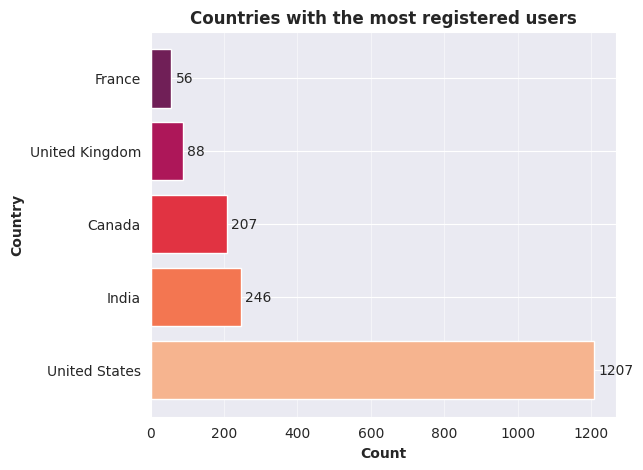

In [ ]:
colors = sns.color_palette("rocket_r")

plt.figure(figsize=(6,5))

bars = plt.barh(
    top_countries_registered.index,
    top_countries_registered.values,
    color=colors)

plt.title("Countries with the most registered users", fontweight="bold")
plt.xlabel("Count", fontweight="semibold")
plt.ylabel("Country", fontweight="semibold")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(top_countries_registered.values)*0.01,  # невеликий відступ
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center'    )

plt.grid(axis='x', alpha=0.5)

plt.show()

#**Sales Dynamics analysis**

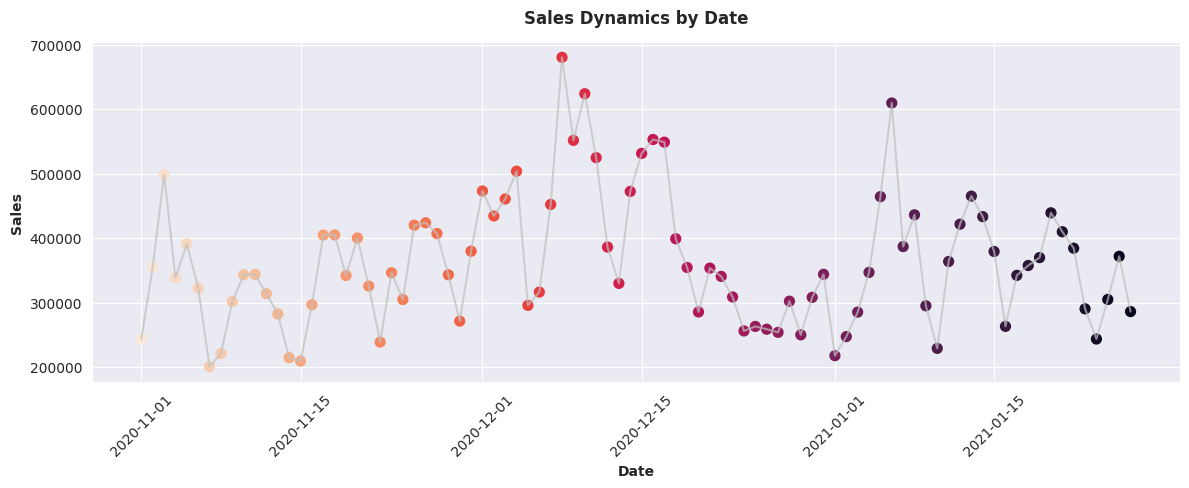

Sales show noticeable volatility over time, with multiple short-term spikes rather than a smooth trend.
**A peak is observed in early December**, followed by a gradual decline toward late December.
Another spike appears in early January, but overall sales stabilize at a lower level afterward.

There are signs of **short-term seasonality**, likely tied to holiday periods (e.g., early December spike).

However, there is **no strong long-term seasonal pattern** within the observed timeframe - fluctuations appear more event-driven than cyclical.

**Takeaway**: Sales dynamics are driven more by **specific peaks (possibly campaigns or holidays)** rather than consistent seasonal trends.

In [ ]:
daily_sales = (
    df.dropna(subset=['order_date', 'price'])
    .groupby('order_date')['price'].sum().sort_index())

plt.figure(figsize=(12,5))
colors = sns.color_palette("rocket_r", len(daily_sales))

plt.scatter(daily_sales.index, daily_sales.values, color=colors, s=50)
plt.plot(daily_sales.index, daily_sales.values, color='silver', alpha=0.7)

plt.title("Sales Dynamics by Date", fontweight='bold', y=1.03)
plt.xlabel("Date", fontweight='semibold')
plt.ylabel("Sales", fontweight='semibold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

display(Markdown("""Sales show noticeable volatility over time, with multiple short-term spikes rather than a smooth trend.
**A peak is observed in early December**, followed by a gradual decline toward late December.
Another spike appears in early January, but overall sales stabilize at a lower level afterward.

There are signs of **short-term seasonality**, likely tied to holiday periods (e.g., early December spike).

However, there is **no strong long-term seasonal pattern** within the observed timeframe - fluctuations appear more event-driven than cyclical.

**Takeaway**: Sales dynamics are driven more by **specific peaks (possibly campaigns or holidays)** rather than consistent seasonal trends."""))

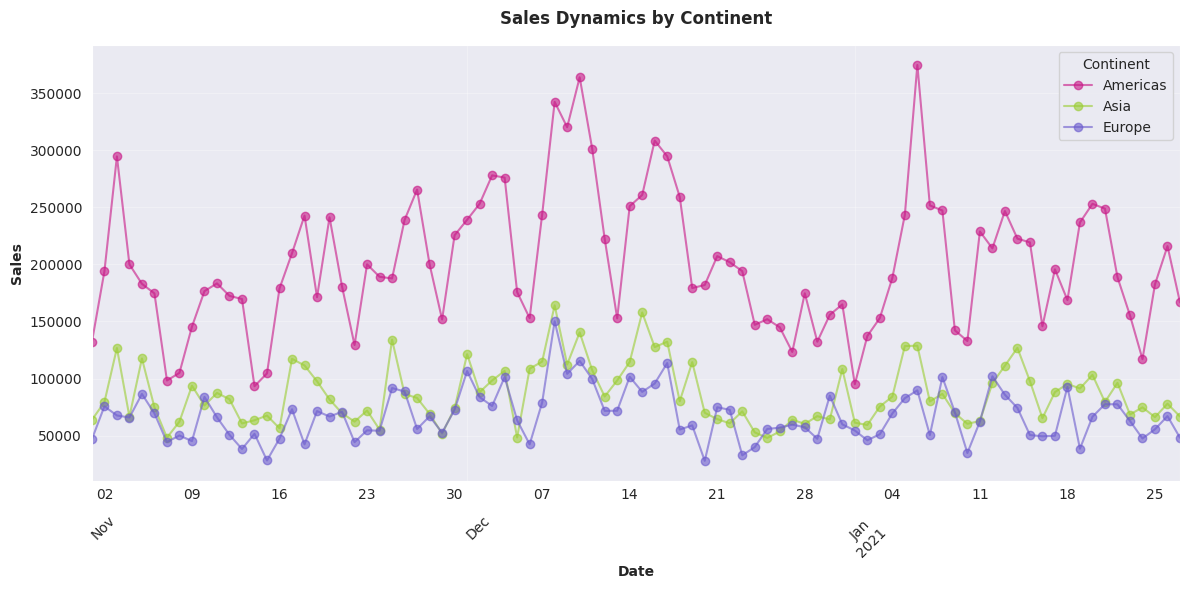

The **Americas** dominate sales with the highest volume and volatility.
**Asia** shows moderate and relatively stable performance.
**Europe** has the lowest sales with smaller fluctuations.

Sales distribution is heavily skewed toward the Americas, while Asia and Europe represent smaller but more stable markets.

Growth opportunities may lie in scaling Asia and Europe, where volatility is lower but potential is not fully realized.

In [ ]:
daily_sales = (
    df[df['continent'].isin(["Americas", "Asia", "Europe"])]
    .groupby(['order_date', 'continent'])['price']
    .sum()
    .unstack()
    .sort_index())

plt.figure(figsize=(12,6))

colors = {
    "Americas": "mediumvioletred",
    "Asia": "yellowgreen",
    "Europe": "slateblue"}

daily_sales.plot(
    ax=plt.gca(),
    marker='o',
    alpha=0.6,
    color=colors)

plt.title("Sales Dynamics by Continent", fontweight="bold", y=1.03)
plt.xlabel("Date", fontweight='semibold')
plt.ylabel("Sales", fontweight='semibold')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend(title="Continent")

plt.tight_layout()
plt.show()

display(Markdown("""The **Americas** dominate sales with the highest volume and volatility.
**Asia** shows moderate and relatively stable performance.
**Europe** has the lowest sales with smaller fluctuations.

Sales distribution is heavily skewed toward the Americas, while Asia and Europe represent smaller but more stable markets.

Growth opportunities may lie in scaling Asia and Europe, where volatility is lower but potential is not fully realized."""))

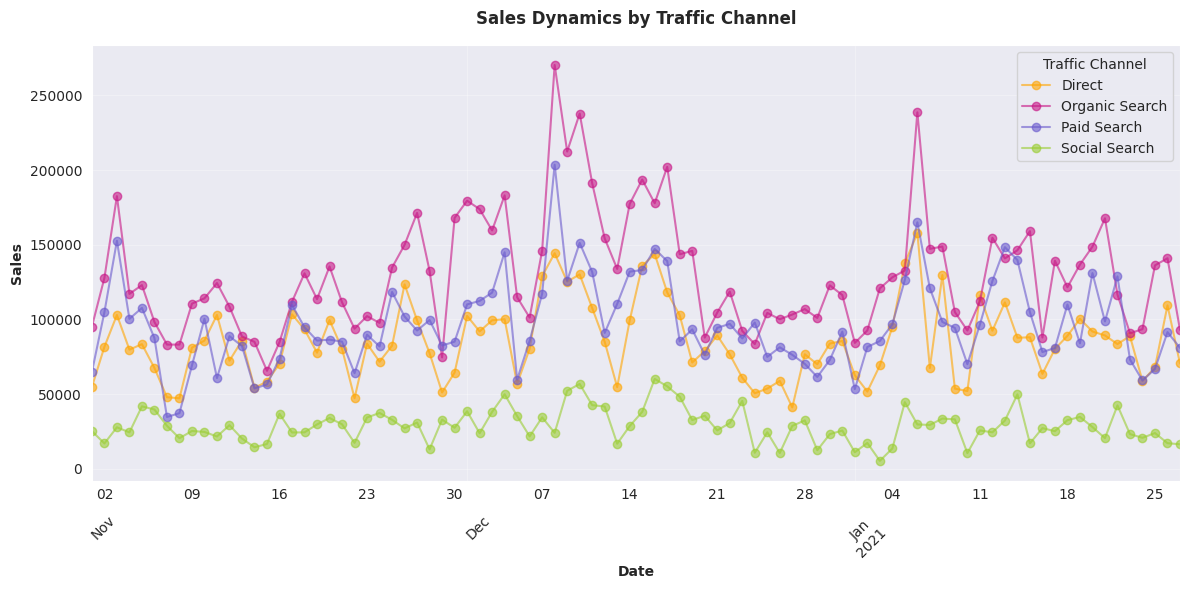

**Organic Search** is the main revenue driver, showing the highest peaks → strongest impact from SEO / high-intent traffic.

**Paid Search** closely follows Organic during spikes → campaigns likely amplify existing demand (works well on peaks).

**Direct** is stable but lower → reflects consistent returning users, not growth driver.

**Social Search** underperforms → low contribution and weak impact on peaks.

All channels spike simultaneously (early Dec, early Jan) → **external/seasonal demand**, not channel-specific effects.

Paid and Organic move almost in sync → **paid likely captures existing demand rather than creating new**.

**Takeaway:**

Core growth: SEO + demand capture

Paid: amplifier, not a primary driver

Social: low ROI candidate

In [ ]:
daily_sales_chan = (
    df[df['traffic_channel'].isin(["Direct", "Organic Search", "Paid Search", "Social Search"])]
    .groupby(['order_date', 'traffic_channel'])['price']
    .sum()
    .unstack()
    .sort_index())

plt.figure(figsize=(12,6))

colors = {
    "Direct": "orange",
    "Organic Search": "mediumvioletred",
    "Paid Search": "slateblue",
    "Social Search": "yellowgreen"}

daily_sales_chan.plot(
    ax=plt.gca(),
    marker='o',
    alpha=0.6,
    color=colors)

plt.title("Sales Dynamics by Traffic Channel", fontweight="bold", y=1.03)
plt.xlabel("Date", fontweight='semibold')
plt.ylabel("Sales", fontweight='semibold')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend(title="Traffic Channel")

plt.tight_layout()
plt.show()

display(Markdown("""**Organic Search** is the main revenue driver, showing the highest peaks → strongest impact from SEO / high-intent traffic.

**Paid Search** closely follows Organic during spikes → campaigns likely amplify existing demand (works well on peaks).

**Direct** is stable but lower → reflects consistent returning users, not growth driver.

**Social Search** underperforms → low contribution and weak impact on peaks.

All channels spike simultaneously (early Dec, early Jan) → **external/seasonal demand**, not channel-specific effects.

Paid and Organic move almost in sync → **paid likely captures existing demand rather than creating new**.

**Takeaway:**

Core growth: SEO + demand capture

Paid: amplifier, not a primary driver

Social: low ROI candidate"""))

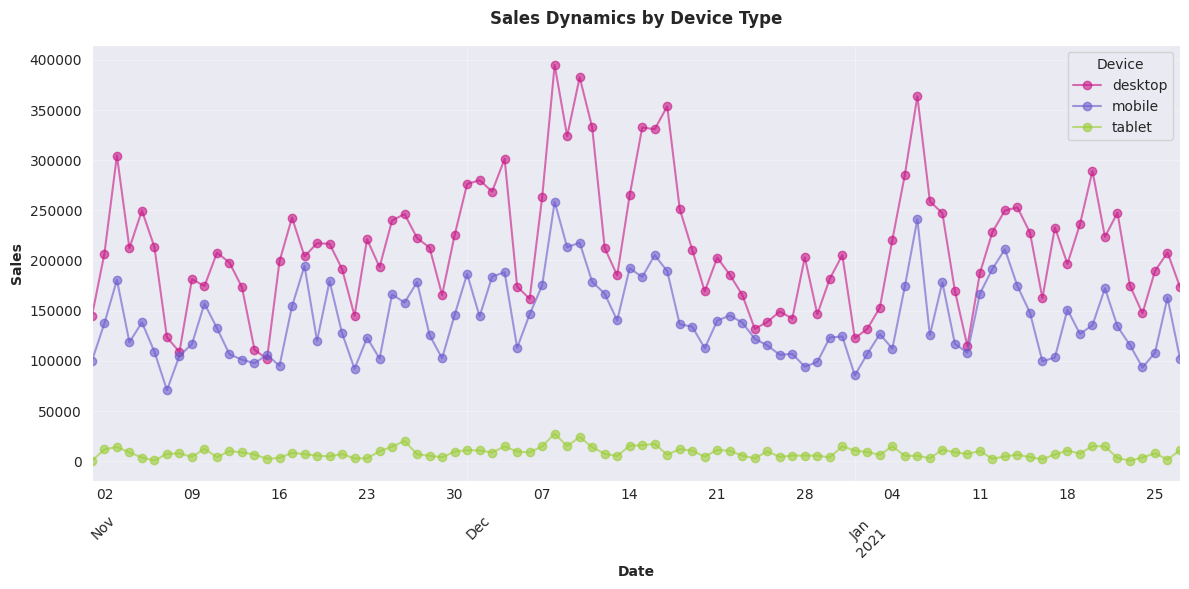

**Desktop** drives the majority of sales with the highest peaks.
**Mobile** follows similar trends at a lower level.
**Tablet** contribution is minimal and stable.

All device types show synchronized peaks (early December, early January) → evidence of seasonal or campaign-driven demand rather than device-specific effects.

The gap between desktop and mobile remains stable, suggesting a structural difference in performance, not temporary fluctuation.

Revenue is heavily desktop-driven, while mobile acts as a secondary channel.
Tablet has negligible impact and may not be a priority for optimization.

In [ ]:
daily_sales_dev = (
    df[df['device'].isin(["desktop", "mobile", "tablet"])]
    .groupby(['order_date', 'device'])['price']
    .sum()
    .unstack()
    .sort_index())

plt.figure(figsize=(12,6))

colors = {
    "desktop": "mediumvioletred",
    "mobile": "slateblue",
    "tablet": "yellowgreen"}

daily_sales_dev.plot(
    ax=plt.gca(),
    marker='o',
    alpha=0.6,
    color=colors)

plt.title("Sales Dynamics by Device Type", fontweight="bold", y=1.03)
plt.xlabel("Date", fontweight='semibold')
plt.ylabel("Sales", fontweight='semibold')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend(title="Device")

plt.tight_layout()
plt.show()

display(Markdown("""**Desktop** drives the majority of sales with the highest peaks.
**Mobile** follows similar trends at a lower level.
**Tablet** contribution is minimal and stable.

All device types show synchronized peaks (early December, early January) → evidence of seasonal or campaign-driven demand rather than device-specific effects.

The gap between desktop and mobile remains stable, suggesting a structural difference in performance, not temporary fluctuation.

Revenue is heavily desktop-driven, while mobile acts as a secondary channel.
Tablet has negligible impact and may not be a priority for optimization."""))

#**Pivot Tables**

In [ ]:
sessions_table = pd.pivot_table(
    df.dropna(subset=['traffic_channel', 'device']),
    index='traffic_channel',
    columns='device',
    aggfunc='size',
    fill_value=0
)

display(Markdown("**Session Count by Device Type and Traffic Channel**"))
sessions_table

**Session Count by Device Type and Traffic Channel**

device,desktop,mobile,tablet
traffic_channel,,,
Direct,4655,2985,160
Organic Search,7011,4655,255
Paid Search,5261,3574,207
Social Search,1594,1065,57
Undefined,1181,834,44


In [ ]:
pivot_table = pd.pivot_table(
    df.dropna(subset=['country', 'product_category', 'price']),
    index='product_category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0
).loc[categories_sales.index, countries_sales.index]

display(Markdown("**Total Sales by top-5 countries in top-10 categories**"))
pivot_table

**Total Sales by top-5 countries in top-10 categories**

country,United States,India,Canada,United Kingdom,France
product_category,,,,,
Sofas & armchairs,3707144.5,788430.0,692427.5,234812.0,187735.0
Chairs,2619773.8,544309.2,417740.8,188519.4,134029.4
Beds,2213058.0,358319.5,354772.0,133816.0,116414.0
Bookcases & shelving units,1567606.9,364507.4,278981.9,113987.6,73830.0
Cabinets & cupboards,994545.5,191888.0,181802.0,71684.5,59101.5
Outdoor furniture,929245.2,162289.4,185322.8,57002.4,40486.4
Tables & desks,777865.0,186157.5,132678.0,49374.0,42299.0
Chests of drawers & drawer units,382388.0,73111.0,71952.0,36784.0,21544.5
Bar furniture,330805.0,57657.0,51724.0,22103.0,11199.0




#**Statistical Analysis of Relationships**

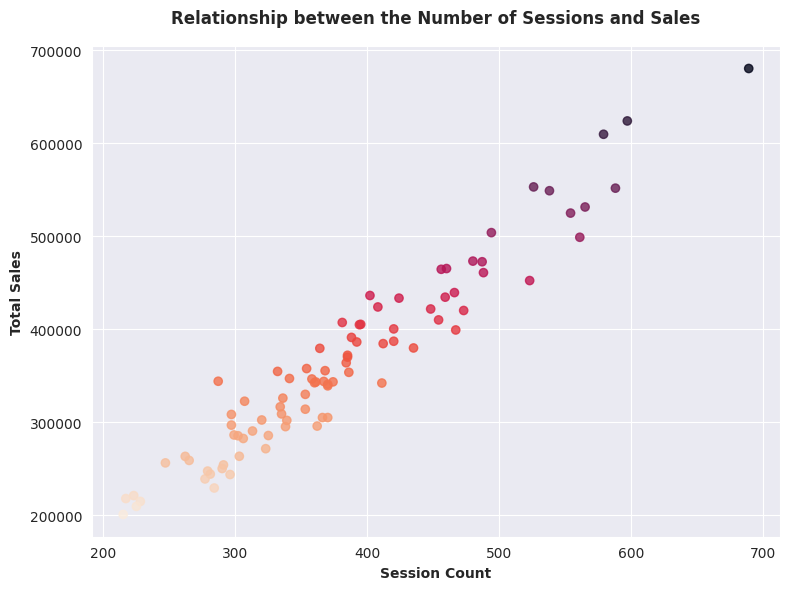

Correlation: 0.96
p-value: 0.000000
Conclusion: the correlation is statistically significant


The correlation coefficient is 0.96, indicating a **very strong positive relationship** between sessions and sales. The **p-value** is effectively zero, which **confirms that this relationship is statistically significant** and unlikely to occur by chance. Overall, this suggests that **as the number of sessions increases, sales also grow proportionally**, making sessions a key driver of revenue.

In [ ]:
# correlation between sales and sessions
clean_df = df.dropna(subset=['order_date', 'price', 'session_id'])

daily_data = (clean_df
.groupby('order_date')
    .agg({
        'price': 'sum',
        'session_id': 'nunique'
    })
    .rename(columns={
        'price': 'daily_sales',
        'session_id': 'daily_sessions'
    })
    .sort_index())

plt.figure(figsize=(8,6))

plt.scatter(
    daily_data['daily_sessions'],
    daily_data['daily_sales'],
    c=daily_data['daily_sales'],
    cmap='rocket_r',
    alpha=0.8)

plt.title("Relationship between the Number of Sessions and Sales", fontweight="bold", y=1.03)
plt.xlabel("Session Count", fontweight="semibold")
plt.ylabel("Total Sales", fontweight="semibold")

plt.tight_layout()
plt.show()

corr, p_value = pearsonr(
    daily_data['daily_sessions'],
    daily_data['daily_sales'])

print(f"Correlation: {corr:.2f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
  print("Conclusion: the correlation is statistically significant")
else:
  print("Conclusion: the correlation is not statistically significant")

display(Markdown("The correlation coefficient is 0.96, indicating a **very strong positive relationship** between sessions and sales. The **p-value** is effectively zero, which **confirms that this relationship is statistically significant** and unlikely to occur by chance. Overall, this suggests that **as the number of sessions increases, sales also grow proportionally**, making sessions a key driver of revenue."))


In [ ]:
# correlation of sales between top3 continents
clean_df = df.dropna(subset=['order_date', 'price', 'continent'])

top_continents = (
    clean_df
    .groupby('continent')['price']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index)

daily_continent_sales = (
    clean_df[clean_df['continent'].isin(top_continents)]
    .groupby(['order_date', 'continent'])['price']
    .sum()
    .unstack()
    .fillna(0)
    .sort_index())

results = []

continents = daily_continent_sales.columns

for i in range(len(continents)):
    for j in range(i+1, len(continents)):
        c1 = continents[i]
        c2 = continents[j]

        corr, p_value = pearsonr(
            daily_continent_sales[c1],
            daily_continent_sales[c2])

        results.append({
            'Continent Pair': f"{c1} vs {c2}",
            'Correlation': round(corr, 2),
            'p-value': round(p_value, 6)})

results_df = pd.DataFrame(results)
print(results_df)

for row in results:
    if row['p-value'] < 0.05:
        print(f"{row['Continent Pair']}: statistically significant")
    else:
        print(f"{row['Continent Pair']}: not significant")

       Continent Pair  Correlation  p-value
0    Americas vs Asia         0.69      0.0
1  Americas vs Europe         0.67      0.0
2      Asia vs Europe         0.67      0.0
Americas vs Asia: statistically significant
Americas vs Europe: statistically significant
Asia vs Europe: statistically significant


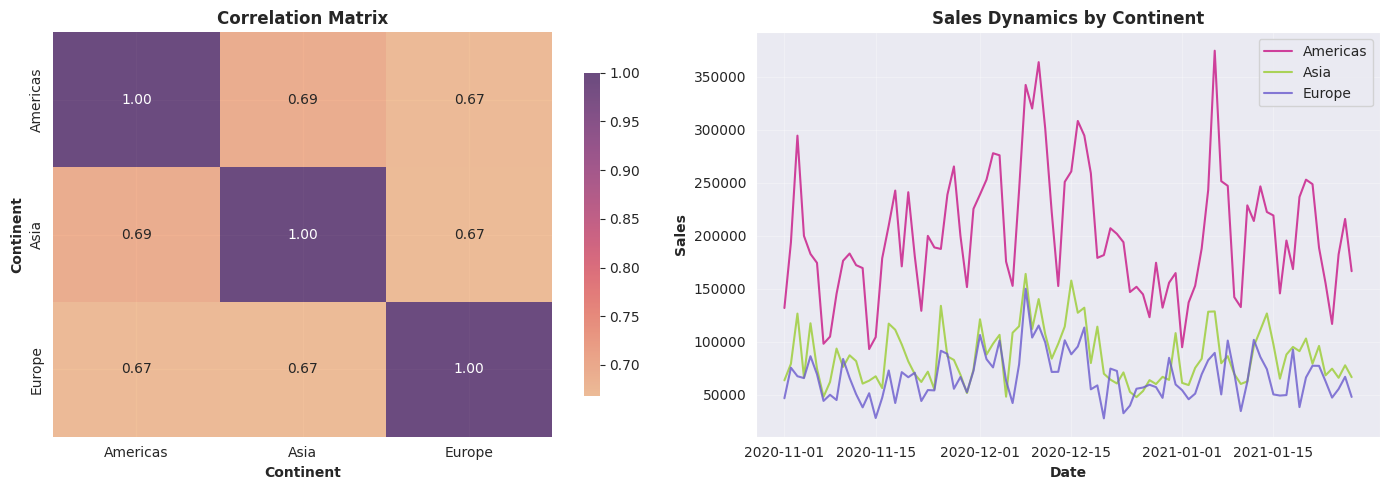

Sales across continents demonstrate **strong positive correlations** (0.67–0.69), all of which are **statistically significant**. This indicates that sales trends in the Americas, Asia, and Europe move consistently together, pointing to global demand drivers rather than region-specific patterns.

In [ ]:
colors = ["mediumvioletred", "yellowgreen", "slateblue"]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# heatmap
sns.heatmap(
   daily_continent_sales.corr(),
    annot=True,
    fmt=".2f",
    cmap="flare",
    alpha=0.8,
    ax=axes[0],
    cbar_kws={"shrink": .8})

axes[0].set_title("Correlation Matrix", fontweight="bold")
axes[0].set_xlabel("Continent", fontweight="semibold")
axes[0].set_ylabel("Continent", fontweight="semibold")

# line chart
for i, col in enumerate(daily_continent_sales.columns):
    axes[1].plot(
        daily_continent_sales.index,
        daily_continent_sales[col],
        label=col,
        color=colors[i % len(colors)],
        alpha=0.8
    )

axes[1].set_title("Sales Dynamics by Continent", fontweight="bold")
axes[1].set_xlabel("Date", fontweight="semibold")
axes[1].set_ylabel("Sales", fontweight="semibold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(Markdown("Sales across continents demonstrate **strong positive correlations** (0.67–0.69), all of which are **statistically significant**. This indicates that sales trends in the Americas, Asia, and Europe move consistently together, pointing to global demand drivers rather than region-specific patterns."))

In [ ]:
# correlation of sales between traffic channels
clean_df = df.dropna(subset=['order_date', 'price', 'traffic_channel'])

daily_channel_sales = (
    clean_df
    .groupby(['order_date', 'traffic_channel'])['price']
    .sum()
    .unstack()
    .fillna(0)
    .sort_index())

results = []

channels = daily_channel_sales.columns

for i in range(len(channels)):
    for j in range(i+1, len(channels)):
        ch1 = channels[i]
        ch2 = channels[j]

        corr, p_value = pearsonr(
            daily_channel_sales[ch1],
            daily_channel_sales[ch2])

        results.append({
            'Channel Pair': f"{ch1} vs {ch2}",
            'Correlation': round(corr, 2),
            'p-value': round(p_value, 6)})

results_df = pd.DataFrame(results)
print(results_df)

for row in results:
    if row['p-value'] < 0.05:
        print(f"{row['Channel Pair']}: statistically significant")
    else:
        print(f"{row['Channel Pair']}: not significant")

                      Channel Pair  Correlation   p-value
0         Direct vs Organic Search         0.76  0.000000
1            Direct vs Paid Search         0.72  0.000000
2          Direct vs Social Search         0.46  0.000006
3              Direct vs Undefined         0.42  0.000038
4    Organic Search vs Paid Search         0.81  0.000000
5  Organic Search vs Social Search         0.43  0.000023
6      Organic Search vs Undefined         0.44  0.000022
7     Paid Search vs Social Search         0.45  0.000010
8         Paid Search vs Undefined         0.43  0.000029
9       Social Search vs Undefined         0.36  0.000585
Direct vs Organic Search: statistically significant
Direct vs Paid Search: statistically significant
Direct vs Social Search: statistically significant
Direct vs Undefined: statistically significant
Organic Search vs Paid Search: statistically significant
Organic Search vs Social Search: statistically significant
Organic Search vs Undefined: statistically sign

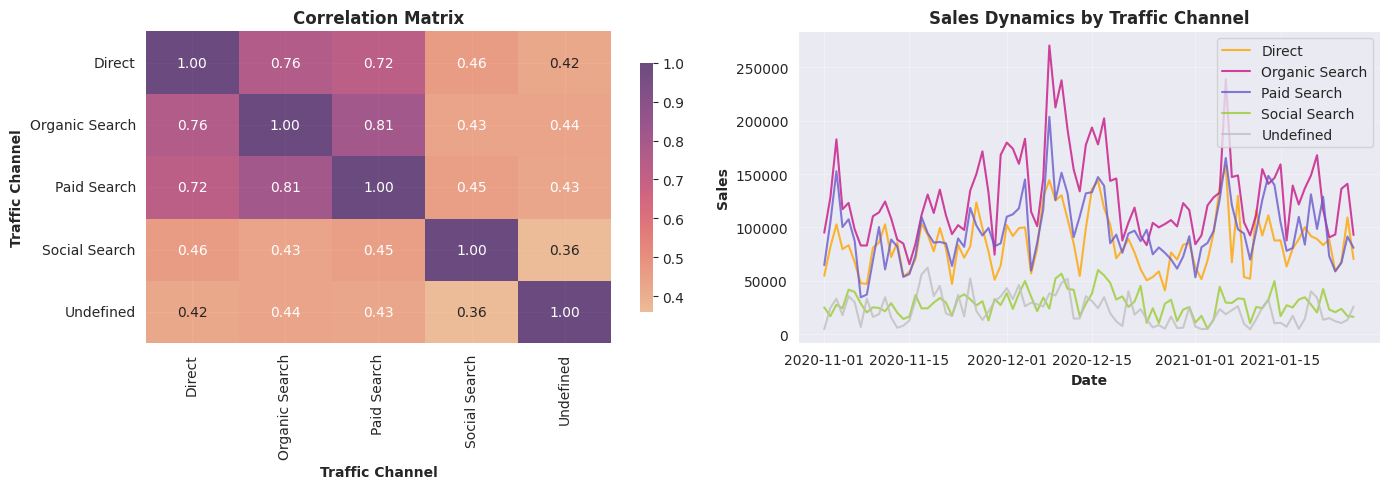

Sales across traffic channels show **moderate to strong positive correlations** (0.36–0.81), all **statistically significant**. The strongest relationship is between Organic and Paid Search, indicating they move in sync and capture shared demand. Overall, channel performance is driven by common external factors rather than independent effects.

In [ ]:
colors = ["orange", "mediumvioletred", "slateblue", "yellowgreen", "silver"]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# heatmap
sns.heatmap(
    daily_channel_sales.corr(),
    annot=True,
    fmt=".2f",
    cmap="flare",
    alpha=0.8,
    ax=axes[0],
    cbar_kws={"shrink": .8})

axes[0].set_title("Correlation Matrix", fontweight="bold")
axes[0].set_xlabel("Traffic Channel", fontweight="semibold")
axes[0].set_ylabel("Traffic Channel", fontweight="semibold")


# line chart
for i, col in enumerate(daily_channel_sales.columns):
    axes[1].plot(
        daily_channel_sales.index,
        daily_channel_sales[col],
        label=col,
        color=colors[i % len(colors)],
        alpha=0.8
    )

axes[1].set_title("Sales Dynamics by Traffic Channel", fontweight="bold")
axes[1].set_xlabel("Date", fontweight="semibold")
axes[1].set_ylabel("Sales", fontweight="semibold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(Markdown("Sales across traffic channels show **moderate to strong positive correlations** (0.36–0.81), all **statistically significant**. The strongest relationship is between Organic and Paid Search, indicating they move in sync and capture shared demand. Overall, channel performance is driven by common external factors rather than independent effects."))

In [ ]:
# correlation of sales between top5 categories
clean_df = df.dropna(subset=['order_date', 'price', 'product_category'])

top_categories = (
    clean_df
    .groupby('product_category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index)

daily_category_sales = (
    clean_df[clean_df['product_category'].isin(top_categories)]
    .groupby(['order_date', 'product_category'])['price']
    .sum()
    .unstack()
    .fillna(0)
    .sort_index())

results = []

categories = daily_category_sales.columns

for i in range(len(categories)):
    for j in range(i+1, len(categories)):
        c1 = categories[i]
        c2 = categories[j]

        corr, p_value = pearsonr(
            daily_category_sales[c1],
            daily_category_sales[c2])

        results.append({
            'Category Pair': f"{c1} vs {c2}",
            'Correlation': round(corr, 2),
            'p-value': round(p_value, 6)})

results_df = pd.DataFrame(results)
print(results_df)

for row in results:
    if row['p-value'] < 0.05:
        print(f"{row['Category Pair']}: statistically significant")
    else:
        print(f"{row['Category Pair']}: not significant")

                                       Category Pair  Correlation  p-value
0                 Beds vs Bookcases & shelving units         0.59      0.0
1                       Beds vs Cabinets & cupboards         0.51      0.0
2                                     Beds vs Chairs         0.55      0.0
3                          Beds vs Sofas & armchairs         0.54      0.0
4  Bookcases & shelving units vs Cabinets & cupbo...         0.54      0.0
5               Bookcases & shelving units vs Chairs         0.64      0.0
6    Bookcases & shelving units vs Sofas & armchairs         0.67      0.0
7                     Cabinets & cupboards vs Chairs         0.57      0.0
8          Cabinets & cupboards vs Sofas & armchairs         0.66      0.0
9                        Chairs vs Sofas & armchairs         0.58      0.0
Beds vs Bookcases & shelving units: statistically significant
Beds vs Cabinets & cupboards: statistically significant
Beds vs Chairs: statistically significant
Beds vs Sofas &

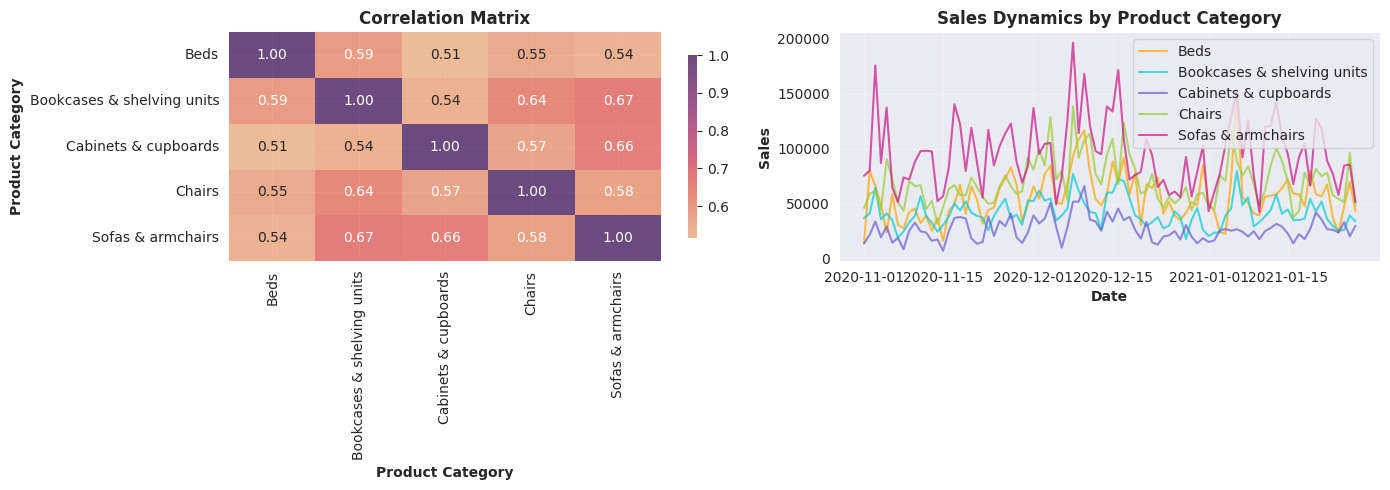

Sales across the top product categories show **moderate positive correlations** (0.51–0.67), and all relationships are **statistically significant** (p-value ≈ 0). This indicates that category sales tend to move together, likely driven by shared demand patterns (e.g., seasonality or promotions) rather than independent behavior.

In [ ]:
colors = ["orange", "darkturquoise", "slateblue", "yellowgreen", "mediumvioletred"]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# heatmap
sns.heatmap(
    daily_category_sales.corr(),
    annot=True,
    fmt=".2f",
    cmap="flare",
    alpha=0.8,
    ax=axes[0],
    cbar_kws={"shrink": .8})

axes[0].set_title("Correlation Matrix", fontweight="bold")
axes[0].set_xlabel("Product Category", fontweight="semibold")
axes[0].set_ylabel("Product Category", fontweight="semibold")


# line chart
for i, col in enumerate(daily_category_sales.columns):
    axes[1].plot(
        daily_category_sales.index,
        daily_category_sales[col],
        label=col,
        color=colors[i % len(colors)],
        alpha=0.7
    )

axes[1].set_title("Sales Dynamics by Product Category", fontweight="bold")
axes[1].set_xlabel("Date", fontweight="semibold")
axes[1].set_ylabel("Sales", fontweight="semibold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(Markdown("Sales across the top product categories show **moderate positive correlations** (0.51–0.67), and all relationships are **statistically significant** (p-value ≈ 0). This indicates that category sales tend to move together, likely driven by shared demand patterns (e.g., seasonality or promotions) rather than independent behavior."))

#**Statistical Analysis of Differences Between Groups**

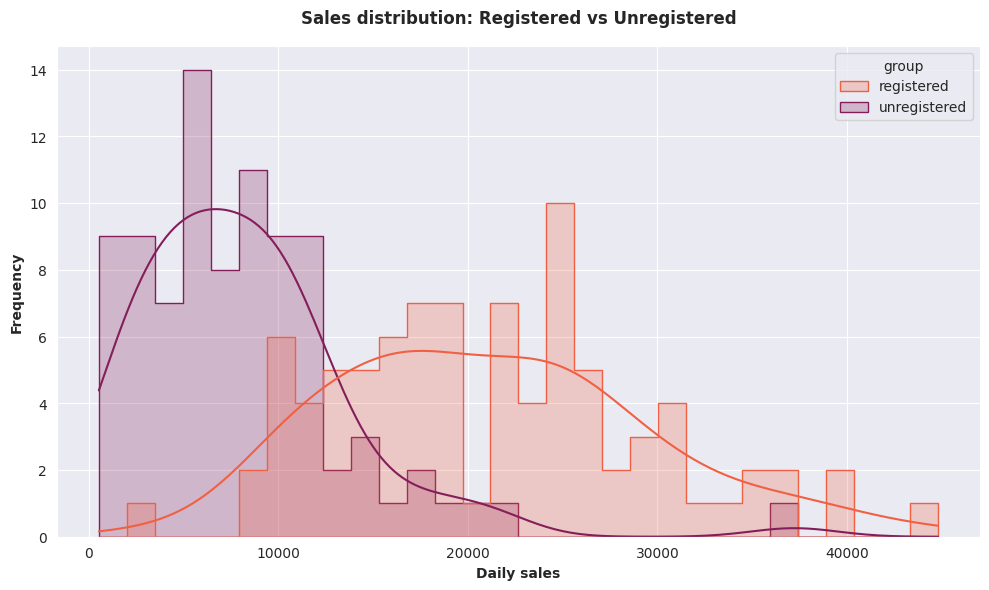

In [ ]:
# daily sales distributions for registered vs unregistered users
clean_df = df.dropna(subset=['order_date', 'price', 'is_email_verified'])
daily_sales = clean_df.groupby(['order_date', 'is_email_verified'])['price'].sum().reset_index()

registered = daily_sales[daily_sales['is_email_verified'] == 1]['price']
unregistered = daily_sales[daily_sales['is_email_verified'] == 0]['price']

plot_df = pd.DataFrame({
    'sales': pd.concat([registered, unregistered]),
    'group': ['registered'] * len(registered) + ['unregistered'] * len(unregistered)
})

plt.figure(figsize=(10,6))

sns.histplot(
    data=plot_df,
    x='sales',
    hue='group',
    kde=True,
    bins=30,
    palette='rocket_r',
    element='step')

plt.title('Sales distribution: Registered vs Unregistered',
          fontweight='bold', y=1.03)

plt.xlabel('Daily sales', fontweight='semibold')
plt.ylabel('Frequency', fontweight='semibold')

plt.tight_layout()
plt.show()

In [ ]:
t_stat, p_value = ttest_ind(
    registered,
    unregistered,
    equal_var=False)

print(f"T-stat: {t_stat:.2f}")
print(f"P-value: {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print("The difference between groups is statistically significant")
else:
    print("The difference between groups is not statistically significant")

display(Markdown("There is a **statistically significant difference** in average daily sales between registered and unregistered users (t = 12.26, p < 0.001). The distribution plot shows a **clear right-shift for registered users**, with consistently higher and more dispersed sales values, while unregistered users are concentrated in the lower range with limited high-value outliers. **Registered users generate higher sales volumes**, confirming their greater value to the business. This indicates that **user registration is a key revenue driver** and should be actively encouraged through improved onboarding and conversion-focused mechanisms."))

T-stat: 12.26
P-value: 1.575e-24
The difference between groups is statistically significant


There is a **statistically significant difference** in average daily sales between registered and unregistered users (t = 12.26, p < 0.001). The distribution plot shows a **clear right-shift for registered users**, with consistently higher and more dispersed sales values, while unregistered users are concentrated in the lower range with limited high-value outliers. **Registered users generate higher sales volumes**, confirming their greater value to the business. This indicates that **user registration is a key revenue driver** and should be actively encouraged through improved onboarding and conversion-focused mechanisms.

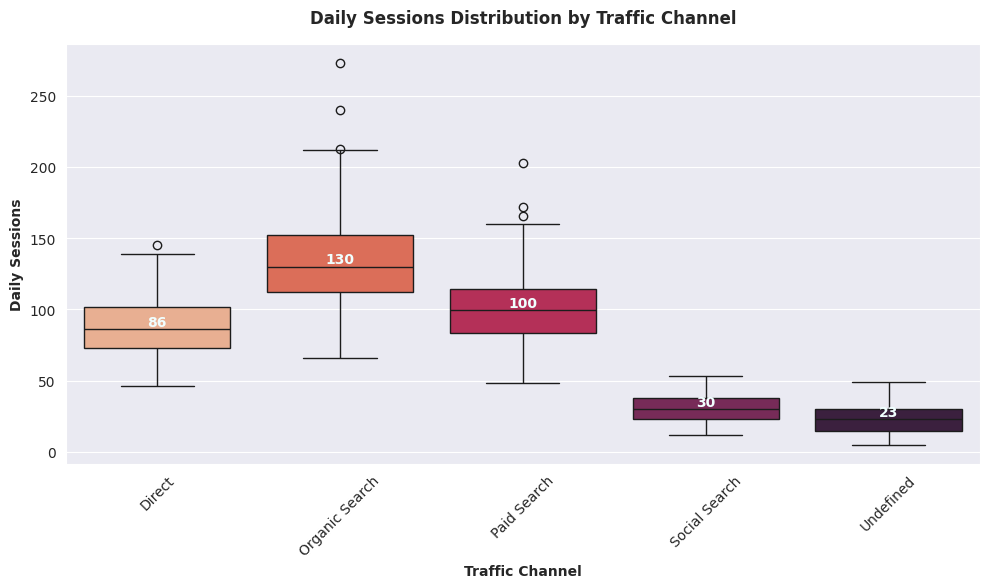

In [ ]:
# session distribution across traffic channels and test for statistical differences
clean_df = df.dropna(subset=['order_date', 'session_id', 'traffic_channel']).copy()

sessions_by_channel = (
    clean_df
    .groupby(['order_date', 'traffic_channel'])['session_id']
    .nunique()
    .reset_index(name='sessions')
)

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=sessions_by_channel,
    x='traffic_channel',
    y='sessions',
    hue='traffic_channel',
    palette='rocket_r',
    legend=False
)

medians = sessions_by_channel.groupby('traffic_channel')['sessions'].median()

for i, (channel, median) in enumerate(medians.items()):
    ax.text(
        i,
        median,
        f'{median:.0f}',
        ha='center',
        va='bottom',
        color='azure',
        fontweight='bold',
        fontsize=10
    )

plt.title("Daily Sessions Distribution by Traffic Channel",
          fontweight="bold", y=1.03)

plt.xlabel("Traffic Channel", fontweight="semibold")
plt.ylabel("Daily Sessions", fontweight="semibold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
groups = [
    group['sessions'].values
    for i, group in sessions_by_channel.groupby('traffic_channel')
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis statistic: {stat:.2f}")
print(f"P-value: {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: there are statistically significant differences in daily sessions across traffic channels.")
else:
    print("Conclusion: no statistically significant differences in daily sessions across traffic channels.")

display(Markdown("Daily sessions **differ significantly across traffic channels** (Kruskal–Wallis p-value ≈ 0), confirming that channel performance is not uniform. **Organic Search leads with the highest median and variability**, followed by Paid and Direct, while **Social and Undefined contribute the least**. This suggests that search-driven channels are the primary drivers of traffic and should be prioritized."))

Kruskal-Wallis statistic: 349.43
P-value: 2.334e-74
Conclusion: there are statistically significant differences in daily sessions across traffic channels.


Daily sessions **differ significantly across traffic channels** (Kruskal–Wallis p-value ≈ 0), confirming that channel performance is not uniform. **Organic Search leads with the highest median and variability**, followed by Paid and Direct, while **Social and Undefined contribute the least**. This suggests that search-driven channels are the primary drivers of traffic and should be prioritized.

In [ ]:
# test difference in organic session share between Europe and America
clean_df = df.dropna(subset=['order_date', 'traffic_channel', 'continent', 'session_id'])

daily_sessions = (
    clean_df
    .groupby(['order_date', 'continent', 'traffic_channel'])['session_id']
    .nunique()
    .reset_index())

total_sessions = (
    daily_sessions
    .groupby(['order_date', 'continent'])['session_id']
    .sum()
    .reset_index(name='total_sessions'))

daily_sessions = daily_sessions.merge(
    total_sessions,
    on=['order_date', 'continent'])

daily_sessions['organic_share'] = (
    daily_sessions['session_id'] / daily_sessions['total_sessions'])

organic = daily_sessions[
    daily_sessions['traffic_channel'] == 'Organic Search']

europe = organic[organic['continent'] == 'Europe']['organic_share']
americas = organic[organic['continent'] == 'Americas']['organic_share']

stat, p_value = mannwhitneyu(europe, americas)

print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Conclusion: the share of organic traffic differs significantly between Europe and the Americas.")
else:
    print("Conclusion: no statistically significant difference in organic traffic share between Europe and the Americas.")

display(Markdown("**The share of organic traffic does not differ significantly between Europe and the Americas** (p-value = 0.565), indicating similar channel mix structures across these regions. This suggests that Organic Search contributes consistently to overall traffic in both markets, and no region-specific adjustment is required for this channel."))

Mann-Whitney U statistic: 4067.0000
p-value: 0.564953
Conclusion: no statistically significant difference in organic traffic share between Europe and the Americas.


**The share of organic traffic does not differ significantly between Europe and the Americas** (p-value = 0.565), indicating similar channel mix structures across these regions. This suggests that Organic Search contributes consistently to overall traffic in both markets, and no region-specific adjustment is required for this channel.

#**Dashboard**

This dashboard analyzes furniture e-commerce sales performance using data processed in BigQuery and explored further in Python. It highlights key business metrics such as revenue, orders, average order value, top-performing product categories, traffic channels, devices, and countries.

The dashboard helps identify the most profitable customer segments and sales drivers, supporting data-driven decisions in marketing, sales, and product strategy through interactive filtering and trend analysis.

[**Dashboard link**](https://public.tableau.com/app/profile/yaryna.rachkovska/viz/FurnitureE-CommercePerformanceAnalytics/SalesAnalytics#1)